# Simple Spam Classifier
This is a simple spam classifier implementation using LogisticRegression and Multinomial Naive Bayes.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt



# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spam-emails/spam.csv


# 1 Load the Data

In [2]:
spam_df = pd.read_csv("/kaggle/input/spam-emails/spam.csv")
spam_df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# 2 Visualize the data
See the distribution of the data here

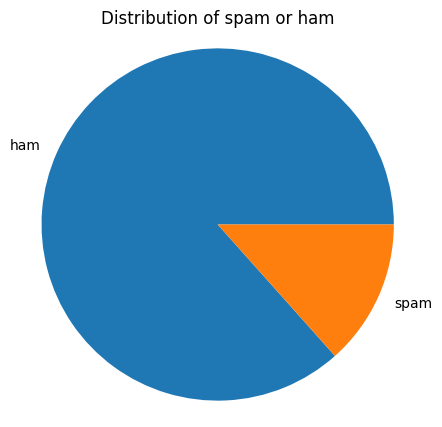

In [3]:
data = spam_df['Category'].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(
    data, 
    labels=data.index
)
plt.title("Distribution of spam or ham")
plt.axis("equal")
plt.show()

# 3 Encode the data to be used by the model
We must prepare the data by encoding the targets (spam/ham)

In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
spam_df['target'] = le.fit_transform(spam_df["Category"])
spam_df.head()

,Category,Message,target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


# 4 Split the training data from the set
Split out 15-20% of the training data

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train,  Y_test = train_test_split(
    spam_df['Message'], 
    spam_df['target'],
    train_size=0.25,
    random_state=42,
    # stratify=y
)

# 5 Vectorize and fit the training data
Since we are working with words, we need to convert the text to numbers in order to let it be used by the model.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(X_train_vec)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 11129 stored elements and shape (1393, 3804)>
  Coords	Values
  (0, 1439)	0.30229562661531506
  (0, 3388)	0.3313827875780908
  (0, 1594)	0.451020347534714
  (0, 2553)	0.3839370970271386
  (0, 2492)	0.46079641483568345
  (0, 3408)	0.48543013702988
  (1, 1439)	0.3085394807848076
  (1, 3717)	0.1998700952252952
  (1, 2369)	0.3782434564172877
  (1, 263)	0.28196271912063636
  (1, 2592)	0.2218309589941711
  (1, 1119)	0.2560653796384754
  (1, 750)	0.2218309589941711
  (1, 3687)	0.20200564578221908
  (1, 526)	0.24091640717296578
  (1, 2943)	0.15746501669287313
  (1, 315)	0.26681374665512675
  (1, 2599)	0.28196271912063636
  (1, 125)	0.28196271912063636
  (1, 3590)	0.28196271912063636
  (1, 135)	0.21202851498882544
  (2, 1439)	0.47786293847706485
  (2, 2369)	0.1952732586912712
  (2, 2481)	0.29113407281999315
  (2, 644)	0.29113407281999315
  :	:
  (1388, 1665)	0.2922245548865844
  (1388, 3719)	0.38671352139107923
  (1388, 1108)	0.29432

# 6 Train the model on the training data
Now that the training data has been prepped to be used in regression models, let's train one.

In [7]:
from sklearn.linear_model import LogisticRegression # The core import for logistic regression


lr = LogisticRegression()
lr.fit(X_train_vec, Y_train)

LogisticRegression()

# 7 Now that we have a basic Logistic Regression model trained, lets see the results.

In [8]:
from sklearn.metrics import accuracy_score # For evaluating the model
y_pred_lr = lr.predict(X_test_vec)

# 7. Evaluate the model
print(f"Model Accuracy: {accuracy_score(Y_test, y_pred_lr)}")

Model Accuracy: 0.9231873653984207


Great! We we're able to get a 92% accuracy. Let's try to improve that by using a different model.

# 8 Attempt with Multinomial Naive Bayes
This model is known to be good for classification problems much like this one, lets see how this affects the results.

In [9]:
from sklearn.naive_bayes import MultinomialNB

# Import and train model 
mnb = MultinomialNB(alpha=1.0, fit_prior=True)
mnb.fit(X_train_vec, Y_train)

# Run predictions
y_pred_mnb = mnb.predict(X_test_vec)

print(f"Model Accuracy: {accuracy_score(Y_test, y_pred_mnb)}")

Model Accuracy: 0.9542952859535774


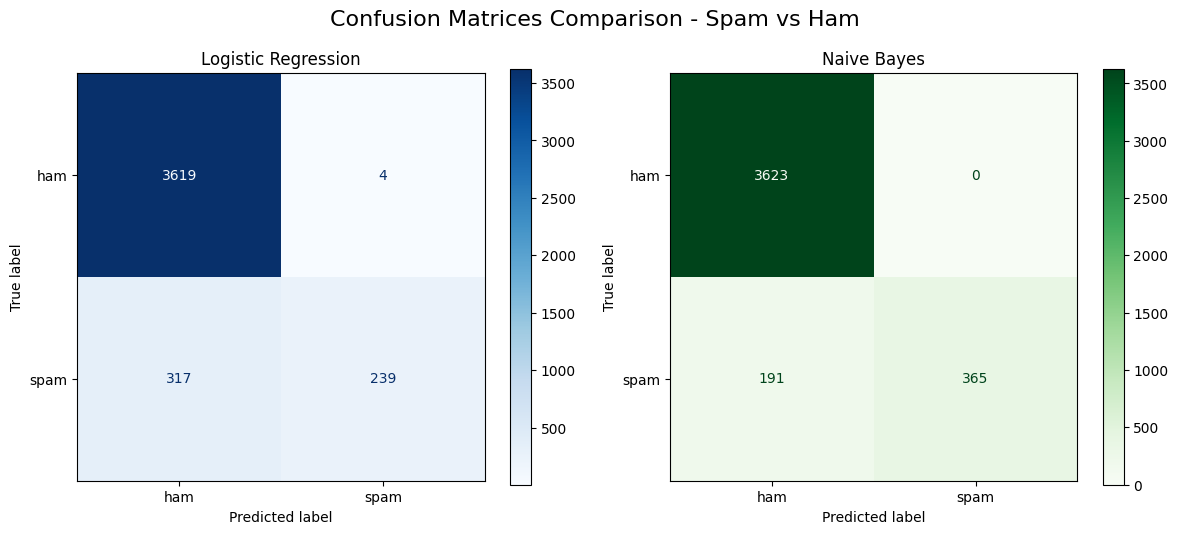

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(Y_test, y_pred_lr)
cm_nb = confusion_matrix(Y_test, y_pred_mnb)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=['ham', 'spam'])
disp_lr.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title('Logistic Regression')

disp_nb = ConfusionMatrixDisplay(cm_nb, display_labels=['ham', 'spam'])
disp_nb.plot(ax=ax2, cmap='Greens', values_format='d')
ax2.set_title('Naive Bayes')

# Optional: overall title
fig.suptitle('Confusion Matrices Comparison - Spam vs Ham', fontsize=16, y=1.02)

plt.tight_layout()  # makes spacing nice
plt.show()
